## tl;dr

- All 37 raw and processed Indy sessions pass checksum, schema, shape, dtype, and finite-value checks.
- Month-to-month drift is material in neural counts: selected-32-channel between-month distance is 1.35x the within-month distance (5,000-label permutation p < 0.001).
- The target behavior changes less cleanly by month: velocity profiles have statistically detectable shifts, but month classification is only 35% and clusters overlap strongly.
- `indy_20170124_01` is not corrupt, but a selected channel is silent during the 60-second prefix and later becomes active, creating a normalization risk if a 1e-6-only scale is used.


## Context & Methods

This diagnostic analyzes the model-facing `counts` and causal `velocity` arrays for all 37 sessions. It compares session-level neural channel-rate profiles, channel composition, target speed/direction distributions, session duration, within-session stability, and causal 60-second calibration behavior. Month separation is measured relative to within-month session variability and validated with 5,000 label permutations.

### Key Assumptions

- Each session is one independent descriptive observation.
- Monthly centroids weight sessions equally so long April/June sessions do not dominate.
- Statistical separation is evidence of distribution drift, not proof that a session is unusable.
- `RECOMPUTE = False` reads the verified outputs. Set it to `True` to rerun the full checksum and permutation workflow.


In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / 'experiments').exists():
    ROOT = Path.cwd().parents[1]
RECOMPUTE = False
if RECOMPUTE:
    from experiments.active.indy_month_drift_analysis import run_analysis
    run_analysis(verify_raw_checksums=True, permutations=5000)

summary = json.loads((ROOT / 'results/metrics/indy_month_drift_analysis.json').read_text())
sessions = pd.read_csv(ROOT / 'results/metrics/indy_session_quality.csv')
months = pd.read_csv(ROOT / 'results/metrics/indy_month_summary.csv')
pairs = pd.read_csv(ROOT / 'results/metrics/indy_month_pairwise.csv')


## Data

The integrity profile below verifies the complete expected inventory before any drift result is interpreted.


In [2]:
pd.DataFrame([{
    'sessions': summary['session_count'],
    'months': summary['month_count'],
    'hours': round(summary['total_duration_hours'], 2),
    'integrity_status': summary['integrity']['status'],
    'integrity_failures': summary['integrity']['failure_count'],
    'raw_checksums_verified': summary['integrity']['raw_checksums_verified'],
}])


,sessions,months,hours,integrity_status,integrity_failures,raw_checksums_verified
0,37,6,8.11,pass,0,True


## Results

Monthly medians show that neural firing level and sparsity move substantially over time, while target RMS speed remains in a narrower range.


In [3]:
months[[
    'month', 'sessions', 'duration_median_min', 'mean_firing_rate_median_hz',
    'count_zero_fraction_median', 'active_channels_ge_1hz_median',
    'speed_rms_median_cm_s', 'stationary_fraction_median',
    'top32_overlap_with_train_selected',
]]


,month,sessions,duration_median_min,mean_firing_rate_median_hz,count_zero_fraction_median,active_channels_ge_1hz_median,speed_rms_median_cm_s,stationary_fraction_median,top32_overlap_with_train_selected
0,2016-04,7,15.886667,17.591859,0.570205,91.0,9.280372,0.419650,0.488372
1,2016-06,4,32.607000,16.581256,0.584552,91.0,9.681951,0.318660,0.454545
2,2016-09,7,6.766667,11.084849,0.671317,86.0,10.425468,0.332182,0.729730
3,2016-10,11,8.366667,8.839404,0.737295,83.0,10.297115,0.321070,0.641026
4,2016-12,4,9.475333,8.542459,0.747701,80.5,9.971707,0.293402,0.361702
5,2017-01,4,11.194000,9.841057,0.717462,92.5,9.431113,0.340321,0.422222


In [4]:
separation_rows = []
for feature_set, result in summary['separation'].items():
    separation_rows.append({
        'feature_set': feature_set,
        'between_within_ratio': result['between_within_ratio'],
        'pseudo_f_p': result['pseudo_f_permutation_p'],
        'month_accuracy': result['leave_one_out_nearest_centroid_accuracy'],
        'null_accuracy': result['accuracy_null_mean'],
        'silhouette': result['silhouette'],
    })
pd.DataFrame(separation_rows)


,feature_set,between_within_ratio,pseudo_f_p,month_accuracy,null_accuracy,silhouette
0,neural_all_96_log_rates,1.299471,0.0002,0.702703,0.170427,0.052650
1,neural_channel_composition,1.303810,0.0002,0.540541,0.170227,-0.015985
2,neural_selected_32_log_rates,1.351025,0.0002,0.729730,0.169546,0.038906
3,velocity_target_profile,1.314291,0.0002,0.351351,0.166195,-0.021560


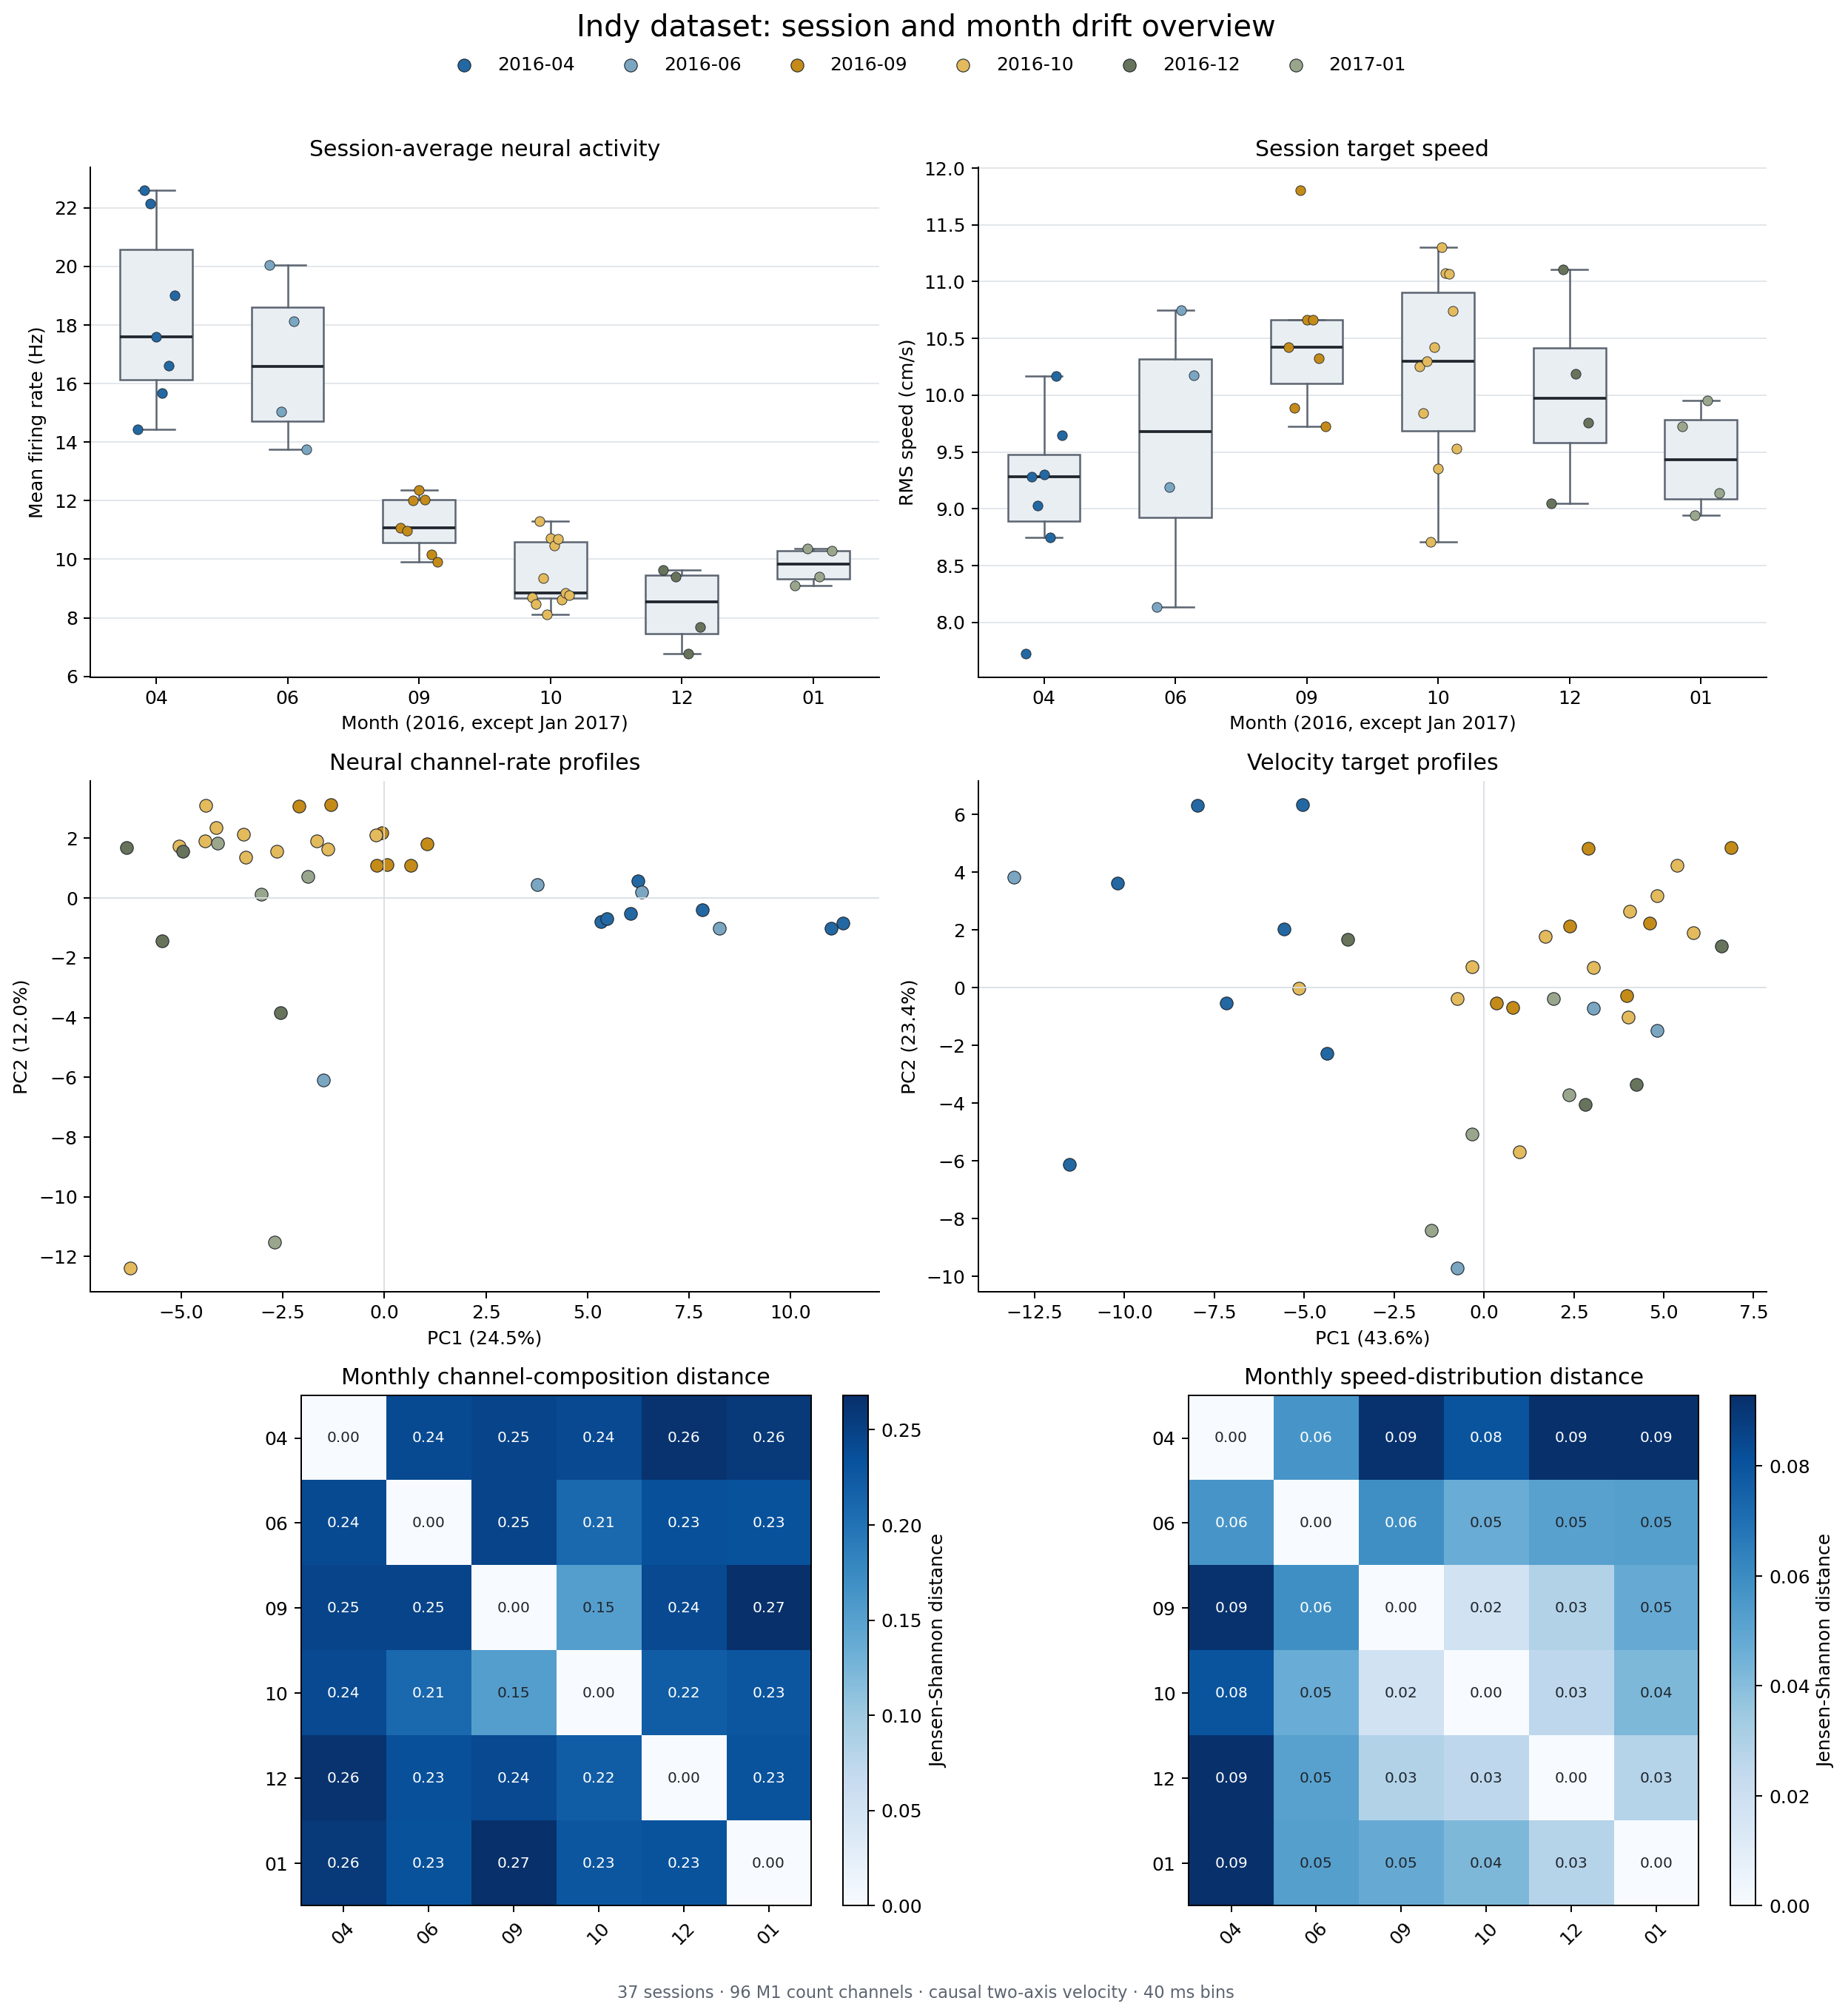

In [5]:
display(Image(filename=ROOT / 'results/figures/indy_month_drift_overview.png'))


Session-level review flags are diagnostic, not automatic exclusion rules. The high-priority case is a causal-prefix normalization edge case rather than a corrupt file.


In [6]:
sessions.loc[sessions['review_priority'] != 'low', [
    'session', 'month', 'review_priority', 'outlier_metrics',
    'prefix_silent_selected_channels', 'naive_prefix_normalized_abs_max',
    'mean_firing_rate_hz', 'speed_rms_cm_s', 'within_session_rate_spearman',
]].sort_values(['review_priority', 'month', 'session'])


,session,month,review_priority,outlier_metrics,prefix_silent_selected_channels,naive_prefix_normalized_abs_max,mean_firing_rate_hz,speed_rms_cm_s,within_session_rate_spearman
34,indy_20170124_01,2017-01,high,NaN,2,1000000.000000,10.359181,8.943999,0.989925
7,indy_20160622_01,2016-06,medium,stationary_fraction,0,14.356646,20.051233,8.137755,0.916589
10,indy_20160630_01,2016-06,medium,NaN,1,179.015819,13.756037,10.174764,0.993243
13,indy_20160921_01,2016-09,medium,speed_rms_cm_s,0,5.749543,12.014658,11.805962,0.991561
28,indy_20161027_03,2016-10,medium,within_session_rate_spearman,2,9.054515,8.775176,9.531318,0.965675
29,indy_20161206_02,2016-12,medium,stationary_fraction,2,12.566571,9.643788,9.045445,0.983739
33,indy_20170123_02,2017-01,medium,stationary_fraction,0,9.465629,9.109014,9.725598,0.991715
36,indy_20170131_02,2017-01,medium,within_session_rate_spearman;population_rate_s...,0,9.569959,10.278882,9.136629,0.974640


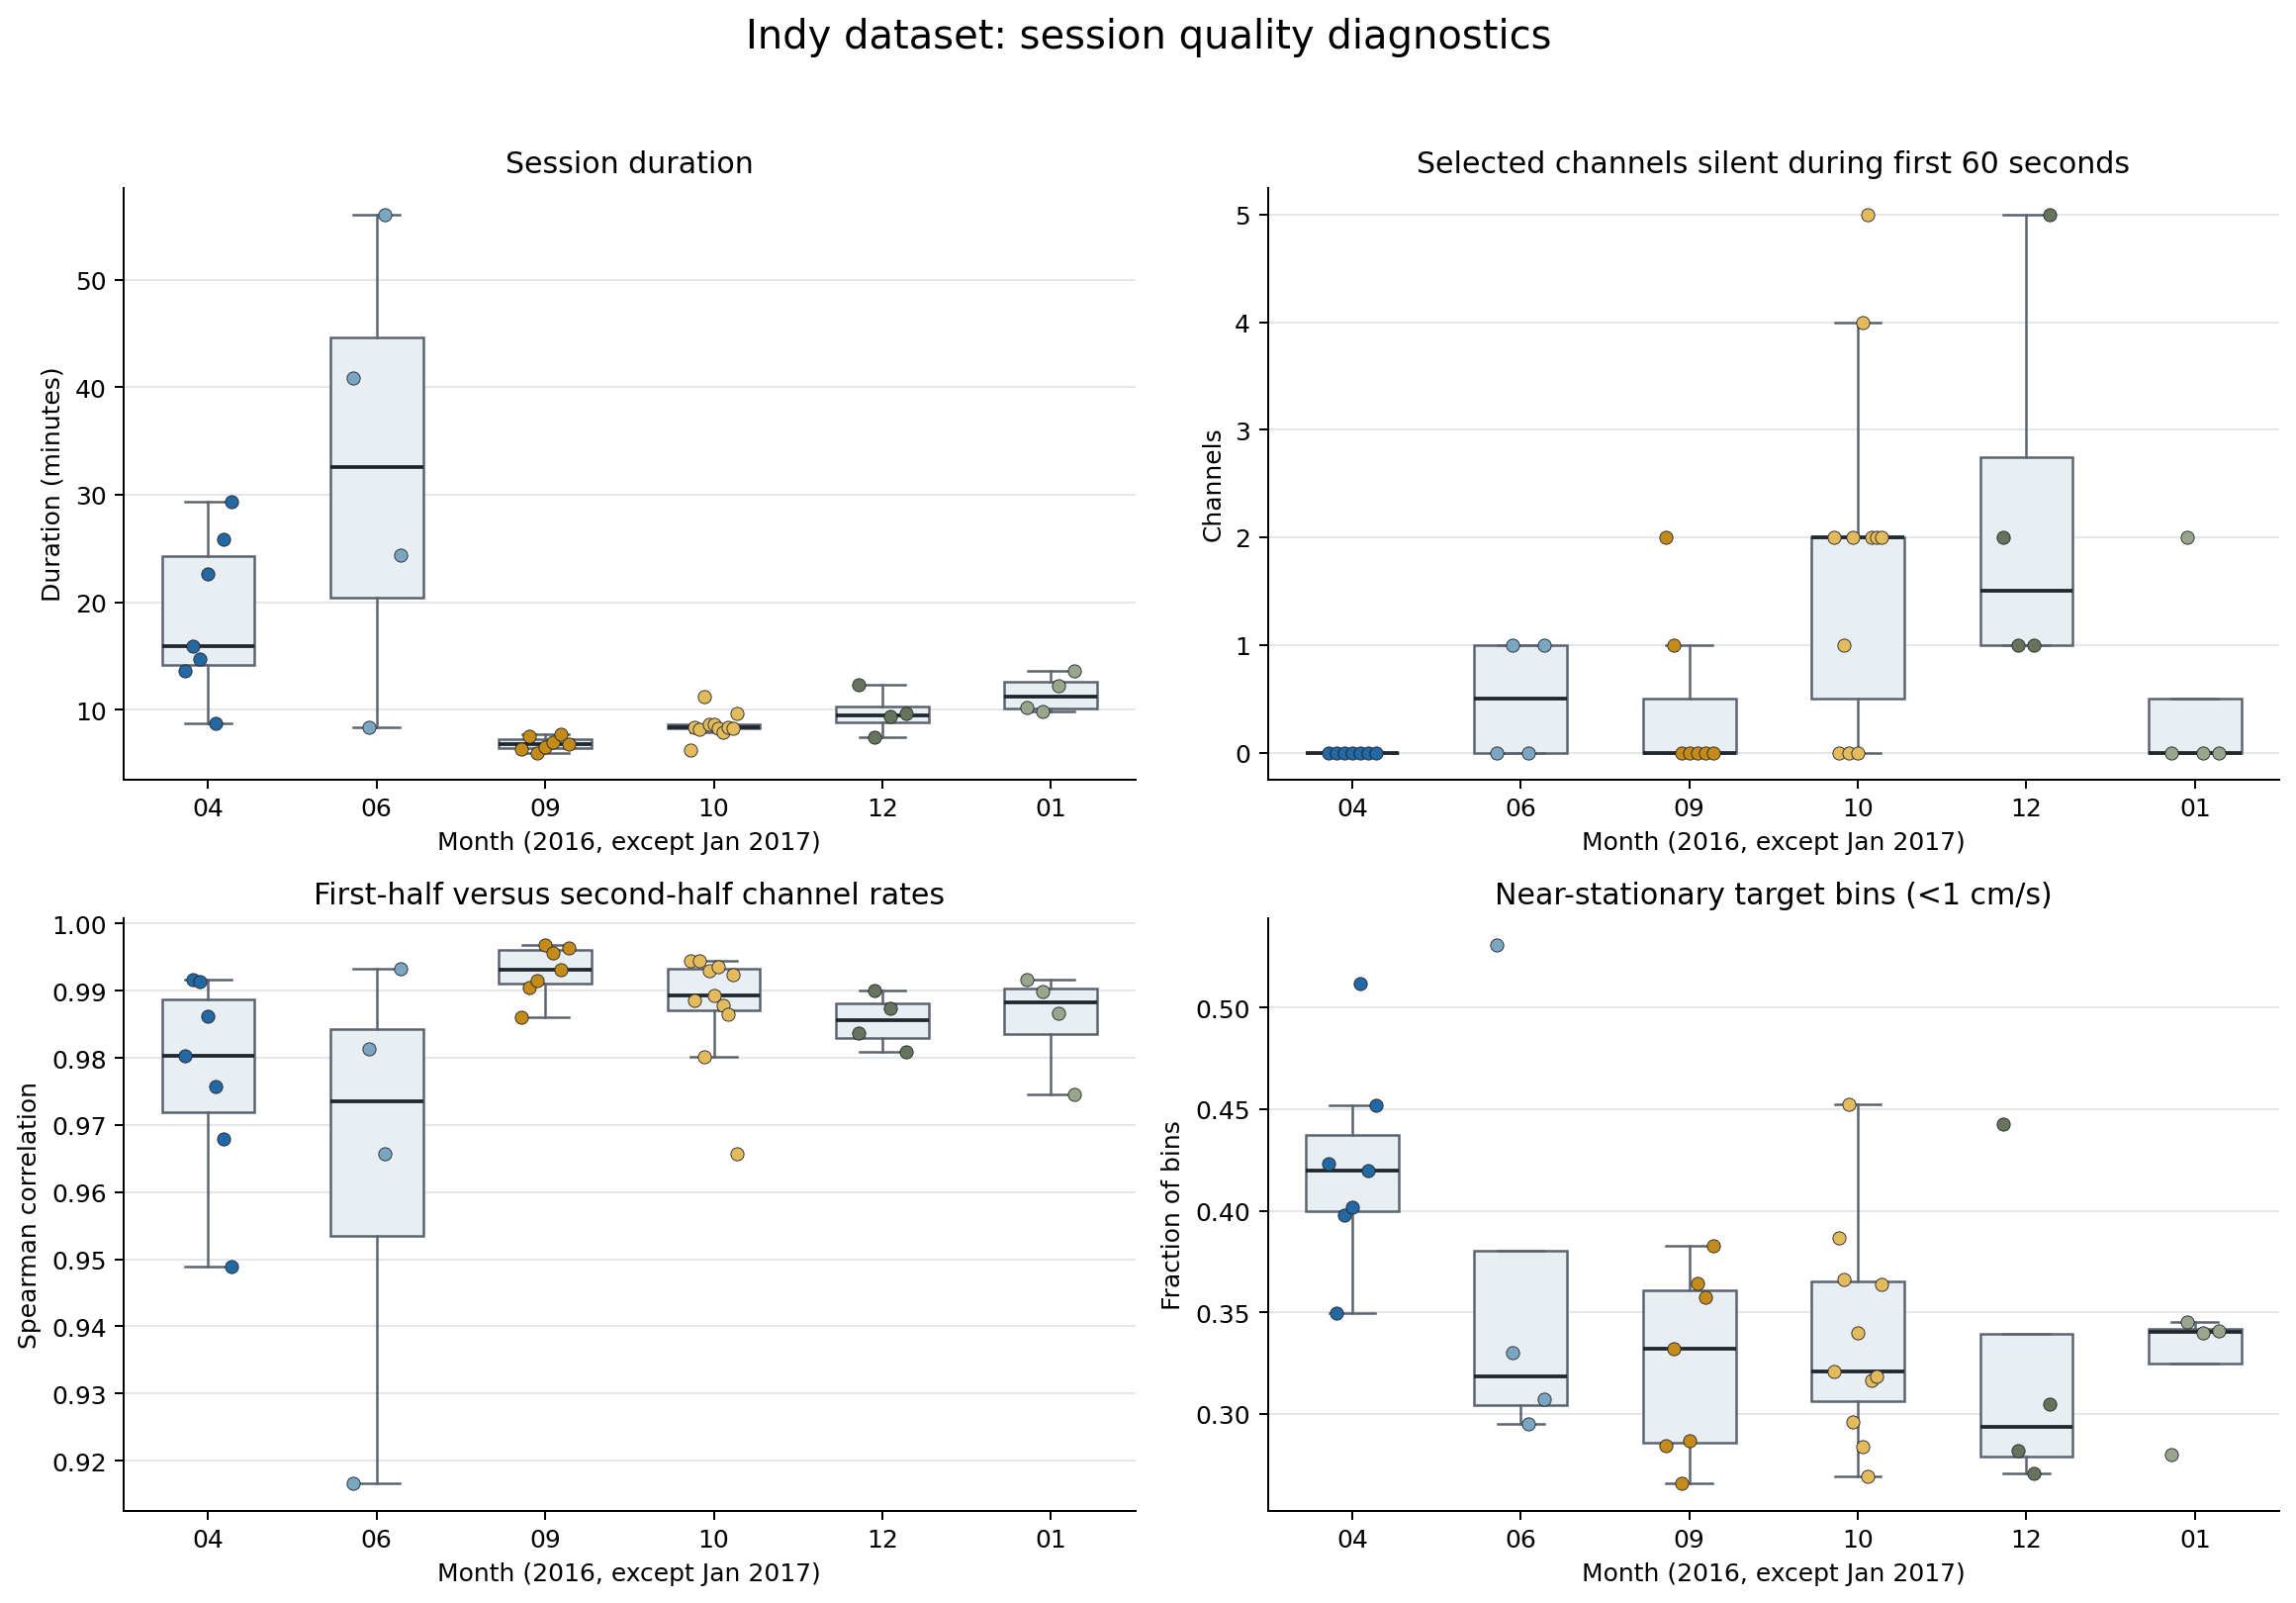

In [7]:
display(Image(filename=ROOT / 'results/figures/indy_session_quality_overview.png'))


## Takeaways

1. Do not discard whole months: all files pass integrity checks and sessions are internally stable.
2. Treat month as a real domain shift: a random-window split would hide it, so validation and test must remain session- and month-separated.
3. Channel selection is not stable enough to assume one month represents all months; evaluate fixed train-selected channels on every later month.
4. Preserve the training-derived standard-deviation floor for causal calibration, especially for `indy_20170124_01`.
5. The next modeling experiment should compare pooled training against recency-weighted or month-balanced training without using January test feedback for selection.
